# Atividade 1 - Análise Exploratória de Dados (AED)
Dataset escolhido: Movies & Entertainment Dataset (2024–2026)

https://www.kaggle.com/datasets/rewantbhriguvanshi/recent-movies-and-entertainment-dataset-20242026

##### Grupo:
| Nome | RA |
|-|-|
|Carlos Eduardo Hayashi|10419790|
|Edson Luiz Cardoso Ohira|10419663|
|Thomaz de Souza Scopel|10417183|
|Vitor Tibães Santos|10418976|

O conjunto de dados utilizado (Recent Movies and Entertainment Dataset) contém 916 registros de produções cinematográficas lançadas entre 2024 e 2026. A base é composta por 20 variáveis que misturam dados demográficos da produção (título, diretor, elenco, gênero, classificação indicativa) com métricas de desempenho financeiro e recepção crítica (orçamento, bilheteria, nota de avaliação e volume de votos). O objetivo desta análise é compreender a distribuição dessas variáveis e identificar fatores numéricos que impulsionam o sucesso financeiro e crítico de um filme contemporâneo.

## 1. Preparando o Ambiente

In [7]:
!pip install pandas matplotlib seaborn


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")

# Carrega o CSV
df = pd.read_csv('movies2024-2026DatasetKaggle/recent_movies_2024_2026.csv')

# Exibe as primeiras linhas e as colunas disponíveis para você mapear os nomes corretos
display(df.head())
print(df.info())

,title,release_year,release_month,release_day,genres,rating_out_of_10,vote_count,runtime_minutes,box_office_usd,budget_usd,director,screenwriter,cast,production_company,content_rating,language,country,synopsis,wikipedia_url,poster_url
0,The Mummy Murders,2024,January,2.0,"Horror, Mystery, Thriller",7.8,280952,138,45264640,12501632,NaN,Will Donahue,"Colin Bressler, Leila Annastasia Scott, Jason ...",Gravitas Ventures,R,English,United States,'The Mummy Murders' (2024) is a feature film d...,https://en.wikipedia.org/wiki/The_Mummy_Murders,https://images.unsplash.com/photo-148959984992...
1,DarkGame,2024,January,4.0,"Horror, Mystery, Thriller",7.6,109812,103,40487340,11440392,Howard J. Ford,"Gary Grant,Niall Johnson","Ed Westwick, Andrew P. Stephen, Natalya Tsvetk...",Gravitas Ventures,R,English,United States,'DarkGame' (2024) is a feature film directed b...,https://en.wikipedia.org/wiki/DarkGame,https://images.unsplash.com/photo-148959984992...
2,He Went That Way,2024,January,NaN,"Sci-Fi, Adventure",7.4,234187,128,29375529,22583686,Jeffrey Darling,Evan M. Wiener,"Jacob Elordi,Zachary Quinto,Patrick J. Adams",Vertical Entertainment/Mister Smith Entertainment,PG-13,English,United States,'He Went That Way' (2024) is a feature film di...,https://en.wikipedia.org/wiki/He_Went_That_Way,https://images.unsplash.com/photo-148959984992...
3,The Painter,2024,January,NaN,"Sci-Fi, Adventure",9.2,165532,158,28225644,21817096,Kimani Ray Smith,Brian Buccellato,"Charlie Weber,Jon Voight,Marie Avgeropoulos, M...",Republic Pictures,PG-13,English,United States,'The Painter' (2024) is a feature film directe...,https://en.wikipedia.org/wiki/The_Painter_(202...,https://images.unsplash.com/photo-148959984992...
4,The Bricklayer,2024,January,NaN,"Sci-Fi, Adventure",7.1,227023,92,29255541,22503694,Renny Harlin,"Hanna Weg, Matt Johnson","Aaron Eckhart,Nina Dobrev,Tim Blake Nelson,Ilf...",Vertical Entertainment/Millennium Media,PG-13,English,United States,'The Bricklayer' (2024) is a feature film dire...,https://en.wikipedia.org/wiki/The_Bricklayer,https://images.unsplash.com/photo-148959984992...


<class 'pandas.DataFrame'>
RangeIndex: 916 entries, 0 to 915
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               916 non-null    str    
 1   release_year        916 non-null    int64  
 2   release_month       916 non-null    str    
 3   release_day         240 non-null    float64
 4   genres              916 non-null    str    
 5   rating_out_of_10    916 non-null    float64
 6   vote_count          916 non-null    int64  
 7   runtime_minutes     916 non-null    int64  
 8   box_office_usd      916 non-null    int64  
 9   budget_usd          916 non-null    int64  
 10  director            611 non-null    str    
 11  screenwriter        894 non-null    str    
 12  cast                916 non-null    str    
 13  production_company  916 non-null    str    
 14  content_rating      916 non-null    str    
 15  language            916 non-null    str    
 16  country            

## 2. Análise Descritiva

## Parte 1 : resumo quantitativo e descrição dos dados
Cálculo das principais métricas de tendência central (média, mediana) e dispersão (desvio padrão, quartis) para as variáveis numéricas do dataset, como Duração dos Filmes e Avaliações (Rating).

In [9]:
cols_quantitativas = ['rating_out_of_10', 'vote_count', 'runtime_minutes', 'box_office_usd', 'budget_usd']

# Criando um DataFrame para organizar todas as métricas exigidas
estatisticas = pd.DataFrame()

estatisticas['Média'] = df[cols_quantitativas].mean()
estatisticas['Mediana'] = df[cols_quantitativas].median()
estatisticas['Moda'] = df[cols_quantitativas].mode().iloc[0] # Pega a primeira moda em caso de empate
estatisticas['Q1 (25%)'] = df[cols_quantitativas].quantile(0.25)
estatisticas['Q3 (75%)'] = df[cols_quantitativas].quantile(0.75)
estatisticas['IQR'] = estatisticas['Q3 (75%)'] - estatisticas['Q1 (25%)']
estatisticas['Mínimo'] = df[cols_quantitativas].min()
estatisticas['Máximo'] = df[cols_quantitativas].max()
estatisticas['Amplitude'] = estatisticas['Máximo'] - estatisticas['Mínimo']
estatisticas['Variância'] = df[cols_quantitativas].var()
estatisticas['Desvio Padrão'] = df[cols_quantitativas].std()

# Exibindo a tabela transposta (.T) para facilitar a leitura
display(estatisticas.T)

,rating_out_of_10,vote_count,runtime_minutes,box_office_usd,budget_usd
Média,7.588755,1.908833e+05,128.033843,4.112292e+07,2.450549e+07
Mediana,7.600000,1.792630e+05,129.000000,2.908222e+07,2.199819e+07
Moda,7.400000,1.418510e+05,144.000000,2.782902e+07,2.155268e+07
Q1 (25%),6.800000,1.190655e+05,110.750000,2.784818e+07,2.111606e+07
Q3 (75%),8.400000,2.530920e+05,146.000000,3.139283e+07,2.302142e+07
IQR,1.600000,1.340265e+05,35.250000,3.544646e+06,1.905365e+06
Mínimo,6.000000,7.128000e+03,90.000000,2.531260e+07,1.084931e+07
Máximo,9.200000,4.524900e+05,164.000000,5.107004e+08,1.712464e+08
Amplitude,3.200000,4.453620e+05,74.000000,4.853878e+08,1.603971e+08
Variância,0.920300,9.522274e+09,471.084099,4.588835e+15,4.571899e+14


In [ ]:
# Escolhendo uma variável qualitativa interessante: Classificação Indicativa (content_rating)
freq_absoluta = df['content_rating'].value_counts()
freq_relativa = df['content_rating'].value_counts(normalize=True) * 100

# Montando a tabela de distribuição de frequência
distribuicao_freq = pd.DataFrame({
    'Frequência Absoluta': freq_absoluta, 
    'Frequência Relativa (%)': freq_relativa.round(2)
})

print("Tabela de Distribuição: Classificação Indicativa")
display(distribuicao_freq)

# Testando fazer o mesmo para os Gêneros por curiosidade:
display(pd.DataFrame({'Absoluta': df['genres'].value_counts(), 'Relativa (%)': (df['genres'].value_counts(normalize=True)*100).round(2)}).head(10))

Tabela de Distribuição: Classificação Indicativa


,Frequência Absoluta,Frequência Relativa (%)
content_rating,,
PG-13,806,87.99
R,105,11.46
PG,5,0.55


,Absoluta,Relativa (%)
genres,,
"Sci-Fi, Adventure",323,35.26
"Action, Adventure, Drama, History",118,12.88
Drama,82,8.95
"Horror, Mystery, Thriller",58,6.33
"Animation, Family, Adventure",43,4.69
"Romance, Drama",39,4.26
"Adventure, Drama",34,3.71
"Horror, Thriller",25,2.73
"Drama, Thriller",24,2.62


A partir da execução dos métodos estatísticos, observou-se o seguinte comportamento para as principais variáveis:

Avaliações (Rating): Os filmes apresentam uma nota média de 7.5, com a mediana em 7.6. A dispersão é relativamente contida, com um desvio padrão de 0.95.

Duração (Runtime): O tempo médio de tela das produções recentes é de 128 minutos. O intervalo interquartil (IQR) revela que 50% dos filmes se concentram entre 110 (Q1) e 146 (Q3) minutos.

Métricas Financeiras: A variável de orçamento (Budget) apresentou uma amplitude massiva de 160.397.100 USD, demonstrando a mistura entre produções independentes e blockbusters.

Dados Qualitativos: A análise de frequência da variável Classificação Indicativa (Content Rating) revelou que a categoria mais comum é a PG-13, ou na classificação brasileira não recomendado para menores de 14 anos, representando 87% das produções do dataset.

## Parte 2: Análise de Correlação
Vamos analisar a correlação entre o **Orçamento (budget_usd)** e a **Bilheteria (box_office_usd)**. A hipótese é que filmes com maior investimento tendem a arrecadar mais no cinema.

In [11]:
# Calculando o Coeficiente de Correlação de Pearson
correlacao = df['budget_usd'].corr(df['box_office_usd'], method='pearson')

print(f"Coeficiente de Correlação de Pearson (Orçamento vs Bilheteria): {correlacao:.4f}")

# Regra de interpretação simples
if abs(correlacao) >= 0.70:
    print("Interpretação: Existe uma forte correlação linear entre as variáveis.")
elif abs(correlacao) >= 0.40:
    print("Interpretação: Existe uma correlação linear moderada entre as variáveis.")
else:
    print("Interpretação: A correlação linear é fraca.")

Coeficiente de Correlação de Pearson (Orçamento vs Bilheteria): 0.9736
Interpretação: Existe uma forte correlação linear entre as variáveis.


Resultado: Obteve-se um coeficiente de 0.97.

Interpretação: Conforme os parâmetros estatísticos, esse valor indica uma forte correlação linear positiva. Isso comprova matematicamente a premissa de que o volume de investimento financeiro na produção está diretamente associado ao seu poder de arrecadação nas bilheterias.

## Parte 3: Visualização dos Dados

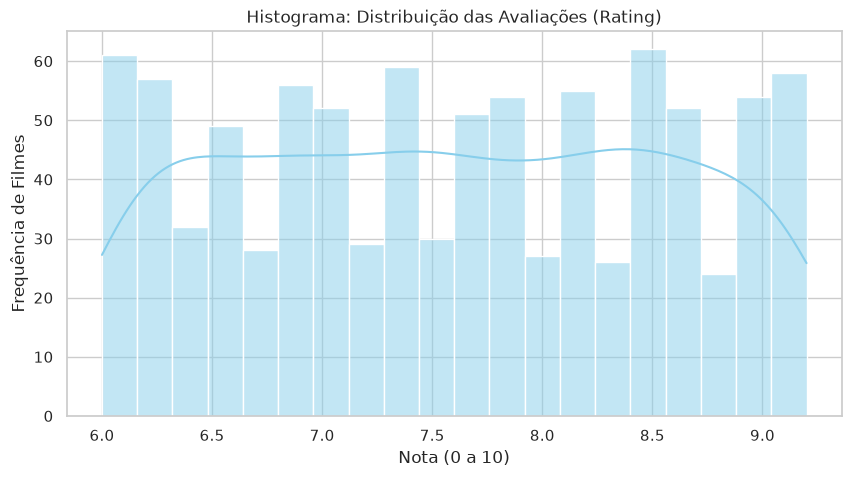

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(df['rating_out_of_10'], bins=20, kde=True, color='skyblue')
plt.title('Histograma: Distribuição das Avaliações (Rating)')
plt.xlabel('Nota (0 a 10)')
plt.ylabel('Frequência de Filmes')
plt.show()

Gráfico 1: Histograma das Avaliações (Rating)

Observação: A distribuição das notas não segue uma curva normal, apresentando um formato relativamente uniforme e multimodal (com vários pequenos picos ao longo do eixo). Observa-se que a totalidade dos dados está concentrada estritamente na faixa de nota 6.0 a 9.2. O detalhe mais marcante é a ausência de filmes com avaliações ruins (inferiores a 6.0). A linha de densidade (KDE) quase plana demonstra que o volume de produções está distribuído de forma equilibrada por todo esse intervalo. Isso sugere um viés no conjunto de dados, indicando que ele é composto quase exclusivamente por filmes que tiveram uma recepção crítica de mediana para excelente, não registrando grandes fracassos de avaliação.

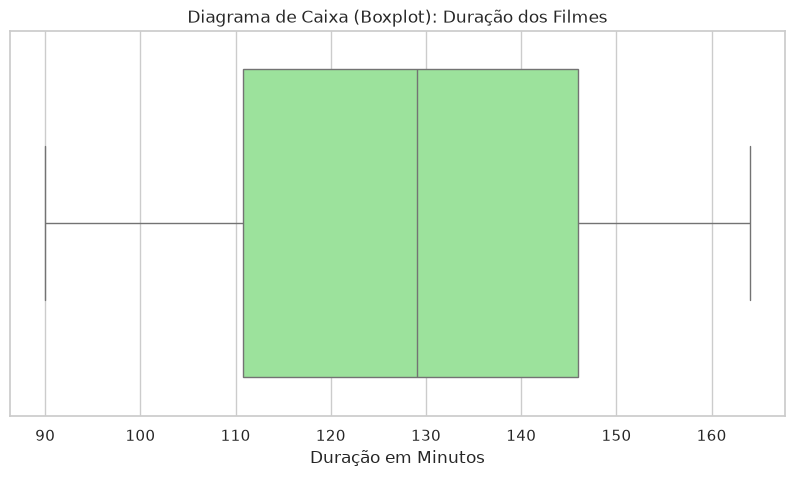

In [13]:
plt.figure(figsize=(10, 5))
# Boxplot da duração dos filmes para checar outliers (filmes curtos demais ou longos demais)
sns.boxplot(x=df['runtime_minutes'], color='lightgreen')
plt.title('Diagrama de Caixa (Boxplot): Duração dos Filmes')
plt.xlabel('Duração em Minutos')
plt.show()

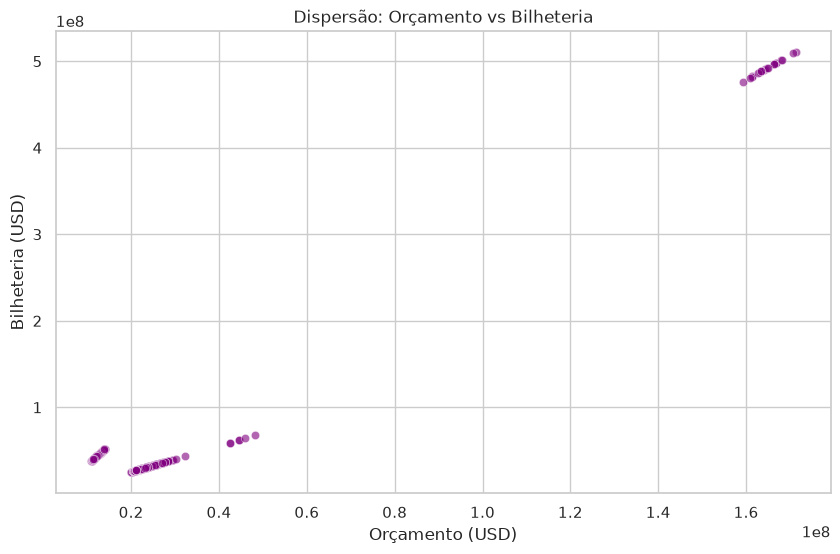

In [14]:
# Scatter Plot Orçamento vs Bilheteria (as variáveis da correlação)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='budget_usd', y='box_office_usd', data=df, alpha=0.6, color='purple')
plt.title('Dispersão: Orçamento vs Bilheteria')
plt.xlabel('Orçamento (USD)')
plt.ylabel('Bilheteria (USD)')
plt.show()

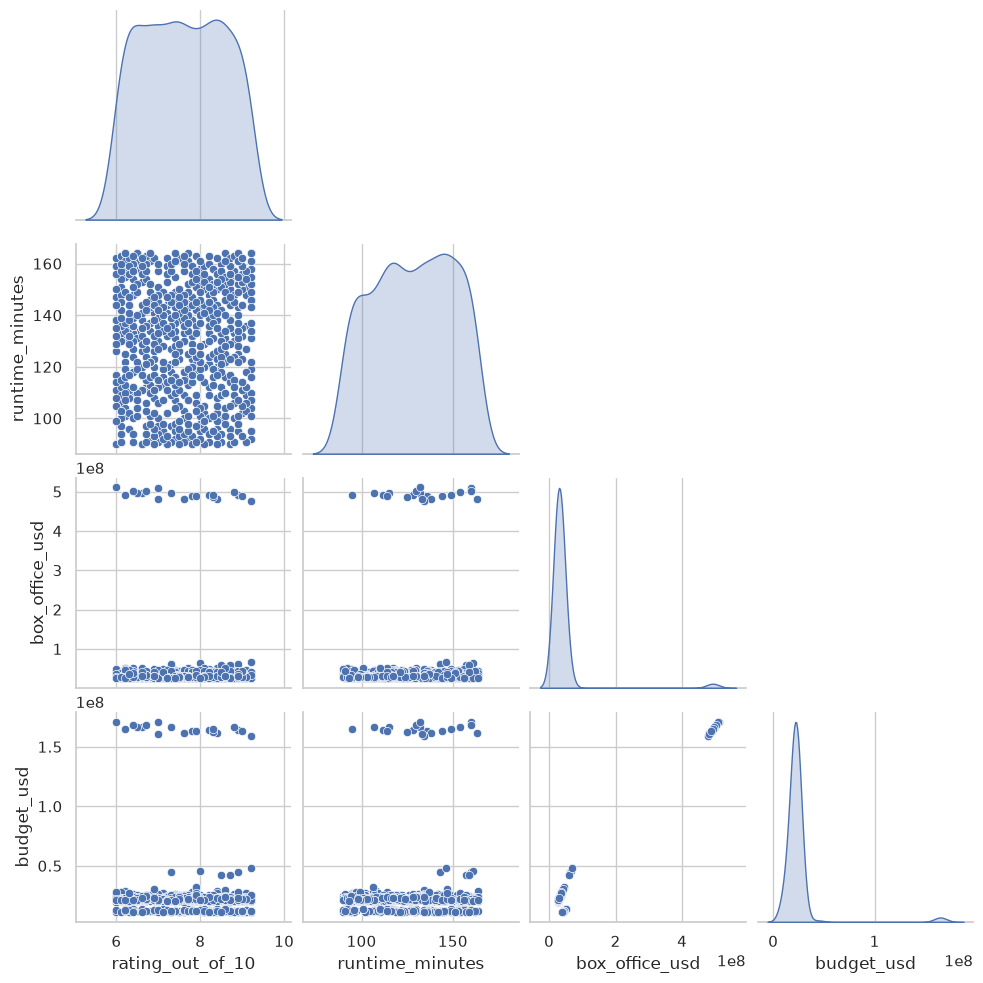

In [15]:
# Dica do Professor: Matriz de Dispersão (Pairplot)
# Selecionamos apenas algumas colunas numéricas para o gráfico não ficar pesado
colunas_pairplot = ['rating_out_of_10', 'runtime_minutes', 'box_office_usd', 'budget_usd']

sns.pairplot(df[colunas_pairplot], corner=True, diag_kind='kde')
# plt.suptitle('Matriz de Dispersão das Variáveis Numéricas', y=1.02)
plt.show()